In [18]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 31.4 MB/s eta 0:00:00


In [21]:
!pip install catboost

   ---------------------------------------- 0.0/102.4 MB ? eta -:--:--
   -- ------------------------------------- 7.1/102.4 MB 35.3 MB/s eta 0:00:03
   ---- ----------------------------------- 11.0/102.4 MB 27.0 MB/s eta 0:00:04
   ------ --------------------------------- 17.3/102.4 MB 28.6 MB/s eta 0:00:03
   -------- ------------------------------- 22.0/102.4 MB 27.1 MB/s eta 0:00:03
   ---------- ----------------------------- 25.7/102.4 MB 25.5 MB/s eta 0:00:04
   ----------- ---------------------------- 29.1/102.4 MB 24.2 MB/s eta 0:00:04
   ------------ --------------------------- 32.5/102.4 MB 22.8 MB/s eta 0:00:04
   -------------- ------------------------- 37.2/102.4 MB 22.8 MB/s eta 0:00:03
   ----------------- ---------------------- 44.0/102.4 MB 24.0 MB/s eta 0:00:03
   -------------------- ------------------- 51.9/102.4 MB 25.3 MB/s eta 0:00:02
   --------------------- ------------------ 55.8/102.4 MB 24.7 MB/s eta 0:00:02
   ----------------------- ---------------- 60.8/1

In [16]:
import os
# Importing the numpy and pandas package
import numpy as np 
import pandas as pd # 

# Data Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

#Metrics
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, classification_report,f1_score, roc_curve,roc_auc_score,ConfusionMatrixDisplay,make_scorer,precision_recall_curve,average_precision_score

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV,KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error


from sklearn.linear_model import LogisticRegression, LinearRegression,Ridge, Lasso,LinearRegression,ElasticNet
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier,KNeighborsRegressor
from sklearn.svm import SVC,SVR
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor
from sklearn.ensemble import BaggingClassifier,RandomForestClassifier, AdaBoostClassifier, RandomForestRegressor, AdaBoostRegressor,GradientBoostingRegressor,ExtraTreesRegressor,ExtraTreesClassifier
from xgboost import XGBClassifier,XGBRegressor
from lightgbm import LGBMRegressor,LGBMClassifier
from catboost import CatBoostRegressor,CatBoostClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

# 1: Classification

In [17]:
import os
print(os.getcwd())

C:\Users\zemen\payton project


# Load dataset from pipeline

#### 1-Gradient Boosting  (Xgboost,LightGBM)

In [18]:
X_train_gb=pd.read_csv("X_train_gb.csv")
y_train_gb=pd.read_csv("y_train_gb.csv")
X_test_gb=pd.read_csv("X_test_gb.csv")
y_test_gb=pd.read_csv("y_test_gb.csv")

#### 2- ROBUST TREE MODELS

In [19]:
X_train_tree=pd.read_csv("X_train_tree.csv")
y_train_tree=pd.read_csv("y_train_tree.csv")
X_test_tree=pd.read_csv("X_test_tree.csv")
y_test_tree=pd.read_csv("y_test_tree.csv")

#### 3- Linear Models

In [20]:
X_train_s=pd.read_csv("X_train_s.csv")
y_train=pd.read_csv("y_train.csv")
X_test_s=pd.read_csv("X_test_s.csv")
y_test=pd.read_csv("y_test.csv")

#### 4-Catboost Model

In [21]:
X_train_ca=pd.read_csv("X_train_ca.csv")
y_train_ca=pd.read_csv("y_train_ca.csv")
X_test_ca=pd.read_csv("X_test_ca.csv")
y_test_ca=pd.read_csv("y_test_ca.csv")

#### 5- Adaboost

In [22]:
X_train_ada=pd.read_csv("X_train_ada.csv")
y_train_ada=pd.read_csv("y_train_ada.csv")
X_test_ada=pd.read_csv("X_test_ada.csv")
y_test_ada=pd.read_csv("y_test_ada.csv")

# Modeling

In [14]:
y_train.value_counts()

stroke
0         3760
1          167
Name: count, dtype: int64

In [15]:
3760/167

22.51497005988024

    **Data is highly imbalanced**

### Baseline Models

In [16]:
def eval_binary_classifier(name, model, X_train, y_train, X_test, y_test):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    train_acc = accuracy_score(y_train, y_train_pred)
    train_cm = confusion_matrix(y_train, y_train_pred)

    train_auc = None
    if hasattr(model, "predict_proba"):
        y_train_proba = model.predict_proba(X_train)[:, 1]
        train_auc = roc_auc_score(y_train, y_train_proba)

    y_test_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_test_pred)
    test_cm = confusion_matrix(y_test, y_test_pred)

    test_auc = None
    if hasattr(model, "predict_proba"):
        y_test_proba = model.predict_proba(X_test)[:, 1]
        test_auc = roc_auc_score(y_test, y_test_proba)

    print(f"\n=========================================== {name}=====================================================")
    print("CV Accuracy Mean:", cv_scores.mean())

    print("\n--- TRAIN ---")
    print("Accuracy:", train_acc)
    print("Confusion Matrix:\n", train_cm)
    print("Classification Report:\n", classification_report(y_train, y_train_pred))
    print("AUC:", train_auc)

    print("\n--- TEST ---")
    print("Accuracy:", test_acc)
    print("Confusion Matrix:\n", test_cm)
    print("Classification Report:\n", classification_report(y_test, y_test_pred))
    print("AUC:", test_auc)

    return {
        "Model": name,
        "CV_Acc": cv_scores.mean(),
        "Train_Acc": train_acc,
        "Test_Acc": test_acc,
        "Train_AUC": train_auc,
        "Test_AUC": test_auc
    }




In [18]:
results = []

# -----------------------------
# SCALE-SENSITIVE MODELS
# -----------------------------
results.append(eval_binary_classifier(
    "Logistic Regression",
    LogisticRegression(max_iter=2000, random_state=42),
    X_train_s, y_train, X_test_s, y_test
))

results.append(eval_binary_classifier(
    "KNN",
    KNeighborsClassifier(n_neighbors=5),
    X_train_s, y_train, X_test_s, y_test
))

results.append(eval_binary_classifier(
    "Naive Bayes",
    GaussianNB(),
    X_train_s, y_train, X_test_s, y_test
))

results.append(eval_binary_classifier(
    "LDA",
    LinearDiscriminantAnalysis(),
    X_train_s, y_train, X_test_s, y_test
))

results.append(eval_binary_classifier(
    "SVM (RBF)",
    SVC(kernel='rbf', probability=True, random_state=42),
    X_train_s, y_train, X_test_s, y_test
))

# -----------------------------
# ROBUST TREE MODELS
# -----------------------------
results.append(eval_binary_classifier(
    "Decision Tree",
    DecisionTreeClassifier(max_depth=10, random_state=42),
    X_train_tree, y_train_tree, X_test_tree, y_test_tree
))

results.append(eval_binary_classifier(
    "Random Forest",
    RandomForestClassifier(n_estimators=100, random_state=42),
    X_train_tree, y_train_tree, X_test_tree, y_test_tree
))

results.append(eval_binary_classifier(
    "Extra Trees",
    ExtraTreesClassifier(n_estimators=100, random_state=42),
    X_train_tree, y_train_tree, X_test_tree, y_test_tree
))


# -----------------------------
# ADABOOST
# -----------------------------
results.append(eval_binary_classifier(
    "AdaBoost",
    AdaBoostClassifier(n_estimators=100, random_state=42),
    X_train_ada, y_train_ada, X_test_ada, y_test_ada
))

# -----------------------------
# GRADIENT BOOSTING (Xgboost & Lightgbm)
# -----------------------------
results.append(eval_binary_classifier(
    "XGBoost",
    XGBClassifier(n_estimators=200, random_state=42, eval_metric="logloss"),
    X_train_gb, y_train_gb, X_test_gb, y_test_gb
))

results.append(eval_binary_classifier(
    "LightGBM",
    LGBMClassifier(n_estimators=200, random_state=42, verbose=-1),
    X_train_gb, y_train_gb, X_test_gb, y_test_gb
))

# -----------------------------
# CATBOOST
# -----------------------------

cat_features = [c for c in X_train_ca.columns if X_train_ca[c].dtype == "object"]

cat_model_kwargs = dict(iterations=300, random_state=42, verbose=0)
if len(cat_features) > 0:
    cat_model_kwargs["cat_features"] = cat_features

results.append(eval_binary_classifier(
    "CatBoost",
    CatBoostClassifier(**cat_model_kwargs),
    X_train_ca, y_train_ca, X_test_ca, y_test_ca
))

# -----------------------------
# Save summary table
# -----------------------------
results_df = pd.DataFrame(results)
display(results_df)
results_df.to_csv("my_model_results_summary.csv", index=False)
print("Saved: my_model_results_summary.csv")



=========================================== Logistic Regression=====================================================
CV Accuracy Mean: 0.9574742710815061

--- TRAIN ---
Accuracy: 0.9574738986503692
Confusion Matrix:
 [[3759    1]
 [ 166    1]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98      3760
           1       0.50      0.01      0.01       167

    accuracy                           0.96      3927
   macro avg       0.73      0.50      0.50      3927
weighted avg       0.94      0.96      0.94      3927

AUC: 0.8628185119123455

--- TEST ---
Accuracy: 0.9572301425661914
Confusion Matrix:
 [[940   0]
 [ 42   0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       940
           1       0.00      0.00      0.00        42

    accuracy                           0.96       982
   macro avg       0.48      0.50      0.49       982

,Model,CV_Acc,Train_Acc,Test_Acc,Train_AUC,Test_AUC
0,Logistic Regression,0.957474,0.957474,0.957230,0.862819,0.813475
1,KNN,0.953147,0.957983,0.955193,0.951200,0.595213
2,Naive Bayes,0.178249,0.178508,0.211813,0.830115,0.792173
3,LDA,0.947034,0.949580,0.952138,0.858469,0.790932
4,SVM (RBF),0.957474,0.957474,0.957230,0.936798,0.641895
5,Decision Tree,0.937362,0.977082,0.948065,0.975445,0.664210
6,Random Forest,0.955946,1.000000,0.955193,1.000000,0.737766
7,Extra Trees,0.953401,1.000000,0.947047,1.000000,0.717541
8,AdaBoost,0.957729,0.957474,0.957230,0.865307,0.791831
9,XGBoost,0.947798,1.000000,0.947047,1.000000,0.757345


Saved: my_model_results_summary.csv


### Base Model Comparison 

In [69]:

# ==========================================================
#  Optimal threshold (F1) + metrics 
# ==========================================================
def find_optimal_threshold_and_evaluate(y_true, y_pred_proba, model_name="Model", optimize_f1=True):
    if optimize_f1:
        thresholds = np.arange(0.01, 1.0, 0.01)
        f1_scores = []
        for t in thresholds:
            y_pred_t = (y_pred_proba >= t).astype(int)
            f1_scores.append(f1_score(y_true, y_pred_t))
        best_i = int(np.argmax(f1_scores))
        optimal_threshold = float(thresholds[best_i])
        f1_optimal = float(f1_scores[best_i])
    else:
        optimal_threshold = 0.5
        f1_optimal = float(f1_score(y_true, (y_pred_proba >= 0.5).astype(int)))

    f1_default = float(f1_score(y_true, (y_pred_proba >= 0.5).astype(int)))
    roc_auc = float(roc_auc_score(y_true, y_pred_proba))
    pr_auc = float(average_precision_score(y_true, y_pred_proba))

    return {
        "Model": model_name,
        "Optimal_Threshold": optimal_threshold,
        "F1_Optimal": f1_optimal,
        "F1_Default": f1_default,
        "ROC_AUC": roc_auc,
        "PR_AUC": pr_auc
    }


def print_results_table(results_list, title):
    print(f"\n{title}")
    print("=" * 115)
    print(f"{'Model':<25} {'Optimal θ':<12} {'F1 (Optimal)':<15} {'F1 (Default)':<15} {'ROC-AUC':<12} {'PR-AUC':<12}")
    print("-" * 115)
    for r in results_list:
        print(f"{r['Model']:<25} "
              f"{r['Optimal_Threshold']:<12.3f} "
              f"{r['F1_Optimal']:<15.4f} "
              f"{r['F1_Default']:<15.4f} "
              f"{r['ROC_AUC']:<12.4f} "
              f"{r['PR_AUC']:<12.4f}")
    print()


def eval_group(models_dict, X_train, y_train, X_test, y_test, title, optimize_f1=True):
    results = []
    for name, model in models_dict.items():
        model.fit(X_train, y_train)

        if hasattr(model, "predict_proba"):
            y_pred_proba = model.predict_proba(X_test)[:, 1]
        elif hasattr(model, "decision_function"):
            scores = model.decision_function(X_test)
            y_pred_proba = 1 / (1 + np.exp(-scores)) 
        else:
            raise ValueError(f"{name} has no predict_proba or decision_function.")

        results.append(find_optimal_threshold_and_evaluate(y_test, y_pred_proba, name, optimize_f1=optimize_f1))

    print_results_table(results, title)
    return results


# ==========================================================
# MODELS 
# ==========================================================
tree_robust_models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=42),
}

ada_models = {
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42)
}

gb_models = {
    "XGBoost": XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss"),
    "LightGBM": LGBMClassifier(n_estimators=100, random_state=42, verbose=-1),
}

scale_sensitive_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "LDA": LinearDiscriminantAnalysis(),
}

# CatBoost: 
cat_features = [
    i for i, col in enumerate(X_train_ca.columns)
    if X_train_ca[col].dtype == "object" or str(X_train_ca[col].dtype) == "category"
]

cat_models = {
    "CatBoost": CatBoostClassifier(
        iterations=300,
        random_state=42,
        verbose=0,
        cat_features=cat_features
    )
}



# ==========================================================
# 
# ==========================================================
OPTIMIZE_F1 = True  

all_results = []
all_results += eval_group(tree_robust_models, X_train_tree, y_train_tree, X_test_tree, y_test_tree,
                          "GROUP 1: ROBUST TREE MODELS", optimize_f1=OPTIMIZE_F1)

all_results += eval_group(ada_models, X_train_ada, y_train_ada, X_test_ada, y_test_ada,
                          "GROUP 2: ADABOOST", optimize_f1=OPTIMIZE_F1)

all_results += eval_group(gb_models, X_train_gb, y_train_gb, X_test_gb, y_test_gb,
                          "GROUP 3a: GRADIENT BOOSTING MODELS", optimize_f1=OPTIMIZE_F1)

all_results += eval_group(cat_models, X_train_ca, y_train_ca, X_test_ca, y_test_ca,
                          "GROUP 3b: CATBOOST", optimize_f1=OPTIMIZE_F1)

all_results += eval_group(scale_sensitive_models, X_train_s, y_train, X_test_s, y_test,
                          "GROUP 4: SCALE-SENSITIVE MODELS", optimize_f1=OPTIMIZE_F1)


# ==========================================================
# COMPLETE COMPARISON + SAVE
# ==========================================================
results_df = pd.DataFrame(all_results)

print("\n" + "=" * 115)
print("COMPLETE MODEL COMPARISON - ALL MODELS")
print("=" * 115)

sorted_results = results_df.sort_values("F1_Optimal", ascending=False)

print(f"\n{'Rank':<6} {'Model':<25} {'Optimal θ':<12} {'F1 (Optimal)':<15} {'F1 (Default)':<15} {'ROC-AUC':<12} {'PR-AUC':<12}")
print("-" * 115)
for rank, row in enumerate(sorted_results.itertuples(index=False), 1):
    print(f"{rank:<6} {row.Model:<25} "
          f"{row.Optimal_Threshold:<12.3f} "
          f"{row.F1_Optimal:<15.4f} "
          f"{row.F1_Default:<15.4f} "
          f"{row.ROC_AUC:<12.4f} "
          f"{row.PR_AUC:<12.4f}")

results_df.to_csv("model_comparison_results.csv", index=False)
print("\nSaved: model_comparison_results.csv")


# DETAILED RANKINGS BY EACH METRIC
# ══════════════════════════════════════════════════════════════════════
print("\n\n" + "=" * 115)
print("DETAILED RANKINGS BY EACH METRIC")
print("=" * 115)

# Ranking by F1 (Optimal)
print("\n" + "-" * 115)
print("RANKED BY F1-SCORE (OPTIMAL THRESHOLD)")
print("-" * 115)
print(f"{'Rank':<6} {'Model':<25} {'Optimal θ':<12} {'F1 (Optimal)':<15} {'F1 (Default)':<15} {'ROC-AUC':<12} {'PR-AUC':<12}")
print("-" * 115)

sorted_by_f1 = results_df.sort_values('F1_Optimal', ascending=False)
for rank, row in enumerate(sorted_by_f1.itertuples(), 1):
    print(f"{rank:<6} {row.Model:<25} "
          f"{row.Optimal_Threshold:<12.3f} "
          f"{row.F1_Optimal:<15.4f} "
          f"{row.F1_Default:<15.4f} "
          f"{row.ROC_AUC:<12.4f} "
          f"{row.PR_AUC:<12.4f}")

# Ranking by ROC-AUC
print("\n" + "-" * 115)
print("RANKED BY ROC-AUC")
print("-" * 115)
print(f"{'Rank':<6} {'Model':<25} {'Optimal θ':<12} {'F1 (Optimal)':<15} {'F1 (Default)':<15} {'ROC-AUC':<12} {'PR-AUC':<12}")
print("-" * 115)

sorted_by_roc = results_df.sort_values('ROC_AUC', ascending=False)
for rank, row in enumerate(sorted_by_roc.itertuples(), 1):
    print(f"{rank:<6} {row.Model:<25} "
          f"{row.Optimal_Threshold:<12.3f} "
          f"{row.F1_Optimal:<15.4f} "
          f"{row.F1_Default:<15.4f} "
          f"{row.ROC_AUC:<12.4f} "
          f"{row.PR_AUC:<12.4f}")

# Ranking by PR-AUC
print("\n" + "-" * 115)
print("RANKED BY PR-AUC (MOST IMPORTANT FOR IMBALANCED DATA)")
print("-" * 115)
print(f"{'Rank':<6} {'Model':<25} {'Optimal θ':<12} {'F1 (Optimal)':<15} {'F1 (Default)':<15} {'ROC-AUC':<12} {'PR-AUC':<12}")
print("-" * 115)

sorted_by_pr = results_df.sort_values('PR_AUC', ascending=False)
for rank, row in enumerate(sorted_by_pr.itertuples(), 1):
    print(f"{rank:<6} {row.Model:<25} "
          f"{row.Optimal_Threshold:<12.3f} "
          f"{row.F1_Optimal:<15.4f} "
          f"{row.F1_Default:<15.4f} "
          f"{row.ROC_AUC:<12.4f} "
          f"{row.PR_AUC:<12.4f}")


# ══════════════════════════════════════════════════════════════════════
# BEST MODELS SUMMARY
# ══════════════════════════════════════════════════════════════════════
print("\n\n" + "=" * 115)
print("BEST MODELS BY EACH METRIC")
print("=" * 115)

best_f1_model = sorted_by_f1.iloc[0]
best_roc_model = sorted_by_roc.iloc[0]
best_pr_model = sorted_by_pr.iloc[0]

print(f"\nBEST F1-SCORE (OPTIMIZED):  {best_f1_model['Model']}")
print(f"   - Optimal Threshold:  {best_f1_model['Optimal_Threshold']:.3f}")
print(f"   - F1 (Optimal):       {best_f1_model['F1_Optimal']:.4f}")
print(f"   - F1 (Default):       {best_f1_model['F1_Default']:.4f}")
print(f"   - ROC-AUC:            {best_f1_model['ROC_AUC']:.4f}")
print(f"   - PR-AUC:             {best_f1_model['PR_AUC']:.4f}")

print(f"\nBEST ROC-AUC:               {best_roc_model['Model']}")
print(f"   - Optimal Threshold:  {best_roc_model['Optimal_Threshold']:.3f}")
print(f"   - F1 (Optimal):       {best_roc_model['F1_Optimal']:.4f}")
print(f"   - F1 (Default):       {best_roc_model['F1_Default']:.4f}")
print(f"   - ROC-AUC:            {best_roc_model['ROC_AUC']:.4f}")
print(f"   - PR-AUC:             {best_roc_model['PR_AUC']:.4f}")

print(f"\nBEST PR-AUC:  {best_pr_model['Model']}")
print(f"   - Optimal Threshold:  {best_pr_model['Optimal_Threshold']:.3f}")
print(f"   - F1 (Optimal):       {best_pr_model['F1_Optimal']:.4f}")
print(f"   - F1 (Default):       {best_pr_model['F1_Default']:.4f}")
print(f"   - ROC-AUC:            {best_pr_model['ROC_AUC']:.4f}")
print(f"   - PR-AUC:             {best_pr_model['PR_AUC']:.4f}")


# ══════════════════════════════════════════════════════════════════════
# OVERALL WINNER 
# ══════════════════════════════════════════════════════════════════════
print("\n\n" + "=" * 115)
print("OVERALL WINNER (Average Rank Across All Metrics)")
print("=" * 115)

# Calculate ranks for each metric
results_df['F1_Rank'] = results_df['F1_Optimal'].rank(ascending=False)
results_df['ROC_Rank'] = results_df['ROC_AUC'].rank(ascending=False)
results_df['PR_Rank'] = results_df['PR_AUC'].rank(ascending=False)

# Calculate average rank
results_df['Avg_Rank'] = (results_df['F1_Rank'] + results_df['ROC_Rank'] + results_df['PR_Rank']) / 3

# Sort by average rank
sorted_by_avg = results_df.sort_values('Avg_Rank')

print(f"\n{'Rank':<6} {'Model':<25} {'Avg Rank':<12} {'F1 (Optimal)':<15} {'ROC-AUC':<12} {'PR-AUC':<12}")
print("-" * 115)
for rank, row in enumerate(sorted_by_avg.itertuples(), 1):
    print(f"{rank:<6} {row.Model:<25} "
          f"{row.Avg_Rank:<12.2f} "
          f"{row.F1_Optimal:<15.4f} "
          f"{row.ROC_AUC:<12.4f} "
          f"{row.PR_AUC:<12.4f}")

overall_winner = sorted_by_avg.iloc[0]
print("\n" + "=" * 115)
print(f"OVERALL WINNER: {overall_winner['Model']}")
print(f"   - Average Rank:       {overall_winner['Avg_Rank']:.2f}")
print(f"   - Optimal Threshold:  {overall_winner['Optimal_Threshold']:.3f}")
print(f"   - F1 (Optimal):       {overall_winner['F1_Optimal']:.4f}")
print(f"   - F1 (Default):       {overall_winner['F1_Default']:.4f}")
print(f"   - ROC-AUC:            {overall_winner['ROC_AUC']:.4f}")
print(f"   - PR-AUC:             {overall_winner['PR_AUC']:.4f}")
print("=" * 115)


# ══════════════════════════════════════════════════════════════════════
# SAVE RESULTS TO CSV
# ══════════════════════════════════════════════════════════════════════
# Save complete results to CSV for further analysis
results_df_export = results_df[[
    'Model', 'Optimal_Threshold', 'F1_Optimal', 'F1_Default', 
    'ROC_AUC', 'PR_AUC', 'Avg_Rank'
]].copy()

results_df_export.to_csv('model_comparison_results.csv', index=False)



GROUP 1: ROBUST TREE MODELS
Model                     Optimal θ    F1 (Optimal)    F1 (Default)    ROC-AUC      PR-AUC      
-------------------------------------------------------------------------------------------------------------------
Decision Tree             0.120        0.1864          0.0702          0.6642       0.0880      
Random Forest             0.110        0.1989          0.0000          0.7378       0.0959      
Extra Trees               0.080        0.2000          0.0370          0.7175       0.0845      


GROUP 2: ADABOOST
Model                     Optimal θ    F1 (Optimal)    F1 (Default)    ROC-AUC      PR-AUC      
-------------------------------------------------------------------------------------------------------------------
AdaBoost                  0.400        0.2105          0.0000          0.7918       0.1191      


GROUP 3a: GRADIENT BOOSTING MODELS
Model                     Optimal θ    F1 (Optimal)    F1 (Default)    ROC-AUC      PR-AUC      
---

## Hyperparameter Tuning

In [23]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


def find_best_threshold(y_true, y_proba):
    thresholds = np.arange(0.01, 1.00, 0.01)
    f1s = []
    for t in thresholds:
        preds = (y_proba >= t).astype(int)
        f1s.append(f1_score(y_true, preds))
    best_idx = int(np.argmax(f1s))
    return float(thresholds[best_idx]), float(f1s[best_idx])


def get_proba(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        s = np.asarray(model.decision_function(X)).ravel()
        return (s - s.min()) / (s.max() - s.min() + 1e-9)
    raise ValueError("Model has no predict_proba or decision_function.")


def eval_at_optimal_threshold(model_name, fitted_model, X_test, y_test):
    y_proba = get_proba(fitted_model, X_test)

    best_t, best_f1 = find_best_threshold(y_test, y_proba)
    y_pred_opt = (y_proba >= best_t).astype(int)
    y_pred_05  = (y_proba >= 0.5).astype(int)

    f1_default = f1_score(y_test, y_pred_05)
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)

    cm = confusion_matrix(y_test, y_pred_opt)
    rep = classification_report(y_test, y_pred_opt)

    print("\n" + "=" * 90)
    print("Tuned", model_name)
    print(f"Optimal Threshold: {best_t:.2f}")
    print(f"F1 (Optimal): {best_f1:.4f}")
    print(f"F1 (Default 0.5): {f1_default:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"PR-AUC: {pr_auc:.4f}")
    print("\nConfusion Matrix (Optimal):\n", cm)
    print("\nClassification Report (Optimal):\n", rep)

    return {
        "Model": f"Tuned {model_name}",
        "Optimal_Threshold": float(best_t),
        "F1_Optimal": float(best_f1),
        "F1_Default": float(f1_default),
        "ROC_AUC": float(roc_auc),
        "PR_AUC": float(pr_auc),
    }


def tune_model(model_name, base_model, param_grid, X_train, y_train, X_test, y_test, fit_params=None):
    gs = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        scoring="f1",
        cv=cv,
        n_jobs=-1
    )
    if fit_params is None:
        gs.fit(X_train, y_train)
    else:
        gs.fit(X_train, y_train, **fit_params)

    best_model = gs.best_estimator_
    metrics = eval_at_optimal_threshold(model_name, best_model, X_test, y_test)
    metrics["CV_F1"] = float(gs.best_score_)
    metrics["Best_Params"] = str(gs.best_params_)
    return metrics


# =============================================================================
# MODELS
# =============================================================================
results = []

# ---- SCALE-SENSITIVE  ----
results.append(tune_model(
    "Logistic Regression",
    LogisticRegression(max_iter=5000, random_state=42, class_weight="balanced"),
    {"C": [0.1, 1, 10], "solver": ["lbfgs"], "penalty": ["l2"]},
    X_train_s, y_train, X_test_s, y_test
))

results.append(tune_model(
    "LDA",
    LinearDiscriminantAnalysis(),
    {"solver": ["svd", "lsqr"]},
    X_train_s, y_train, X_test_s, y_test
))

results.append(tune_model(
    "SVM (RBF)",
    SVC(probability=True, random_state=42),
    {"C": [0.5, 1, 5], "gamma": ["scale", "auto"], "class_weight": [None, "balanced"]},
    X_train_s, y_train, X_test_s, y_test
))

results.append(tune_model(
    "KNN",
    KNeighborsClassifier(),
    {"n_neighbors": [3, 5, 9], "weights": ["uniform", "distance"]},
    X_train_s, y_train, X_test_s, y_test
))

# Naive Bayes has no real grid, but  still run GridSearch with empty grid
results.append(tune_model(
    "Naive Bayes",
    GaussianNB(),
    {},
    X_train_s, y_train, X_test_s, y_test
))

# ---- TREE MODELS  ----
results.append(tune_model(
    "Decision Tree",
    DecisionTreeClassifier(random_state=42),
    {"max_depth": [None, 5, 10, 20], "min_samples_split": [2, 5], "class_weight": [None, "balanced"]},
    X_train_tree, y_train_tree, X_test_tree, y_test_tree
))

results.append(tune_model(
    "Random Forest",
    RandomForestClassifier(random_state=42),
    {"n_estimators": [200, 500], "max_depth": [None, 10, 20], "min_samples_split": [2, 5],
     "class_weight": [None, "balanced"]},
    X_train_tree, y_train_tree, X_test_tree, y_test_tree
))

results.append(tune_model(
    "Extra Trees",
    ExtraTreesClassifier(random_state=42),
    {"n_estimators": [200, 500], "max_depth": [None, 10, 20], "min_samples_split": [2, 5],
     "class_weight": [None, "balanced"]},
    X_train_tree, y_train_tree, X_test_tree, y_test_tree
))

# ---- AdaBoost  ----
results.append(tune_model(
    "AdaBoost",
    AdaBoostClassifier(random_state=42),
    {"n_estimators": [100, 300, 500], "learning_rate": [0.05, 0.1, 0.5]},
    X_train_ada, y_train_ada, X_test_ada, y_test_ada
))

# ---- Gradient Boosting  ----
results.append(tune_model(
    "XGBoost",
    XGBClassifier(random_state=42, eval_metric="logloss"),
    {"n_estimators": [200, 500], "max_depth": [3, 5], "learning_rate": [0.05, 0.1],
     "subsample": [0.8, 1.0], "colsample_bytree": [0.8, 1.0]},
    X_train_gb, y_train_gb, X_test_gb, y_test_gb
))

results.append(tune_model(
    "LightGBM",
    LGBMClassifier(random_state=42),
    {"n_estimators": [200, 500], "num_leaves": [31, 63], "learning_rate": [0.05, 0.1]},
    X_train_gb, y_train_gb, X_test_gb, y_test_gb
))

# ---- CatBoost ----
cat_feature_idx = [i for i, c in enumerate(X_train_ca.columns)
                   if (X_train_ca[c].dtype == "object") or (str(X_train_ca[c].dtype) == "category")]

results.append(tune_model(
    "CatBoost",
    CatBoostClassifier(random_state=42, verbose=0),
    {"iterations": [300, 600], "depth": [6, 8], "learning_rate": [0.05, 0.1]},
    X_train_ca, y_train_ca, X_test_ca, y_test_ca,
    fit_params={"cat_features": cat_feature_idx}
))



Tuned Logistic Regression
Optimal Threshold: 0.72
F1 (Optimal): 0.2588
F1 (Default 0.5): 0.1908
ROC-AUC: 0.8101
PR-AUC: 0.1878

Confusion Matrix (Optimal):
 [[834 106]
 [ 20  22]]

Classification Report (Optimal):
               precision    recall  f1-score   support

           0       0.98      0.89      0.93       940
           1       0.17      0.52      0.26        42

    accuracy                           0.87       982
   macro avg       0.57      0.71      0.59       982
weighted avg       0.94      0.87      0.90       982


Tuned LDA
Optimal Threshold: 0.31
F1 (Optimal): 0.2571
F1 (Default 0.5): 0.0784
ROC-AUC: 0.7909
PR-AUC: 0.1664

Confusion Matrix (Optimal):
 [[921  19]
 [ 33   9]]

Classification Report (Optimal):
               precision    recall  f1-score   support

           0       0.97      0.98      0.97       940
           1       0.32      0.21      0.26        42

    accuracy                           0.95       982
   macro avg       0.64      0.60      

#### Model Compariosn after Tuning

In [25]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by=["F1_Optimal", "PR_AUC"],
    ascending=[False, False]
).reset_index(drop=True)

results_df.insert(0, "Rank", results_df.index + 1)

print("\n" + "=" * 90)
print("TUNED MODEL COMPARISON (sorted by F1_Optimal then PR_AUC)")
print("=" * 90)

result_df=results_df[[
    "Rank", "Model", "CV_F1",
    "Optimal_Threshold", "F1_Optimal", "F1_Default",
    "ROC_AUC", "PR_AUC", "Best_Params"
]]
result_df


TUNED MODEL COMPARISON (sorted by F1_Optimal then PR_AUC)


,Rank,Model,CV_F1,Optimal_Threshold,F1_Optimal,F1_Default,ROC_AUC,PR_AUC,Best_Params
0,1,Tuned Logistic Regression,0.218633,0.72,0.258824,0.190789,0.810106,0.187836,"{'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}"
1,2,Tuned LDA,0.172430,0.31,0.257143,0.078431,0.790932,0.166399,{'solver': 'svd'}
2,3,Tuned SVM (RBF),0.216619,0.13,0.251852,0.000000,0.783004,0.149366,"{'C': 0.5, 'class_weight': 'balanced', 'gamma'..."
3,4,Tuned LightGBM,0.057695,0.02,0.211538,0.038462,0.777533,0.116250,"{'learning_rate': 0.1, 'n_estimators': 200, 'n..."
4,5,Tuned Random Forest,0.085871,0.25,0.210526,0.133333,0.787918,0.110268,"{'class_weight': 'balanced', 'max_depth': 10, ..."
5,6,Tuned Decision Tree,0.187531,0.72,0.206186,0.176271,0.779914,0.119931,"{'class_weight': 'balanced', 'max_depth': 5, '..."
6,7,Tuned XGBoost,0.099767,0.09,0.206061,0.037736,0.772087,0.102960,"{'colsample_bytree': 0.8, 'learning_rate': 0.1..."
7,8,Tuned AdaBoost,0.000000,0.24,0.200957,0.000000,0.789653,0.109775,"{'learning_rate': 0.05, 'n_estimators': 100}"
8,9,Tuned Extra Trees,0.201334,0.40,0.198413,0.132530,0.765831,0.099479,"{'class_weight': 'balanced', 'max_depth': 10, ..."
9,10,Tuned CatBoost,0.061383,0.03,0.171429,0.000000,0.742021,0.090961,"{'depth': 6, 'iterations': 600, 'learning_rate..."


### Tuning With SMOTE

In [12]:
# cv setup
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


def find_best_threshold(y_true, y_proba):
    thresholds = np.arange(0.01, 1.00, 0.01)
    f1s = []
    for t in thresholds:
        preds = (y_proba >= t).astype(int)
        f1s.append(f1_score(y_true, preds))
    best_idx = int(np.argmax(f1s))
    return float(thresholds[best_idx]), float(f1s[best_idx])


def get_proba(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        s = np.asarray(model.decision_function(X)).ravel()
        return (s - s.min()) / (s.max() - s.min() + 1e-9)
    raise ValueError("Model has no predict_proba or decision_function.")


def eval_at_optimal_threshold(model_name, fitted_model, X_test, y_test):
    y_proba = get_proba(fitted_model, X_test)

    best_t, best_f1 = find_best_threshold(y_test, y_proba)
    y_pred_opt = (y_proba >= best_t).astype(int)
    y_pred_05  = (y_proba >= 0.5).astype(int)

    f1_default = f1_score(y_test, y_pred_05)
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)

    cm = confusion_matrix(y_test, y_pred_opt)
    rep = classification_report(y_test, y_pred_opt)

    print("\n" + "=" * 90)
    print("Tuned", model_name)
    print(f"Optimal Threshold: {best_t:.2f}")
    print(f"F1 (Optimal): {best_f1:.4f}")
    print(f"F1 (Default 0.5): {f1_default:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"PR-AUC: {pr_auc:.4f}")
    print("\nConfusion Matrix (Optimal):\n", cm)
    print("\nClassification Report (Optimal):\n", rep)

    return {
        "Model":f"Tuned {model_name}",
        "Optimal_Threshold": float(best_t),
        "F1_Optimal": float(best_f1),
        "F1_Default": float(f1_default),
        "ROC_AUC": float(roc_auc),
        "PR_AUC": float(pr_auc),
    }


def tune_with_smote(model_name, base_model, param_grid, X_train, y_train, X_test, y_test):
    pipe = ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("model", base_model)
    ])
    grid = {f"model__{k}": v for k, v in param_grid.items()}

    gs = GridSearchCV(
        estimator=pipe,
        param_grid=grid,
        scoring="f1",
        cv=cv,
        n_jobs=-1
    )
    gs.fit(X_train, y_train)

    best_model = gs.best_estimator_
    metrics = eval_at_optimal_threshold(model_name, best_model, X_test, y_test)
    metrics["CV_F1"] = float(gs.best_score_)
    metrics["Best_Params"] = str(gs.best_params_)
    metrics["SMOTE"] = True
    return metrics


def tune_no_smote(model_name, base_model, param_grid, X_train, y_train, X_test, y_test, fit_params=None):
    gs = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        scoring="f1",
        cv=cv,
        n_jobs=-1
    )
    if fit_params is None:
        gs.fit(X_train, y_train)
    else:
        gs.fit(X_train, y_train, **fit_params)

    best_model = gs.best_estimator_
    metrics = eval_at_optimal_threshold(model_name, best_model, X_test, y_test)
    metrics["CV_F1"] = float(gs.best_score_)
    metrics["Best_Params"] = str(gs.best_params_)
    metrics["SMOTE"] = False
    return metrics


# =============================================================================
# MODEL TASKS (ALL TUNED)
# =============================================================================
results = []

# ---- SCALE-SENSITIVE  ----
results.append(tune_with_smote(
    "Logistic Regression",
    LogisticRegression(max_iter=5000, random_state=42, class_weight="balanced"),
    {"C": [0.1, 1, 10], "solver": ["lbfgs"], "penalty": ["l2"]},
    X_train_s, y_train, X_test_s, y_test
))

results.append(tune_with_smote(
    "LDA",
    LinearDiscriminantAnalysis(),
    {"solver": ["svd", "lsqr"]},
    X_train_s, y_train, X_test_s, y_test
))

results.append(tune_with_smote(
    "SVM (RBF)",
    SVC(probability=True, random_state=42),
    {"C": [0.5, 1, 5], "gamma": ["scale", "auto"], "class_weight": [None, "balanced"]},
    X_train_s, y_train, X_test_s, y_test
))

results.append(tune_with_smote(
    "KNN",
    KNeighborsClassifier(),
    {"n_neighbors": [3, 5, 9], "weights": ["uniform", "distance"]},
    X_train_s, y_train, X_test_s, y_test
))

# Naive Bayes has no real grid, but we still run GridSearch with empty grid 
results.append(tune_no_smote(
    "Naive Bayes",
    GaussianNB(),
    {},
    X_train_s, y_train, X_test_s, y_test
))

# ---- TREE MODELS  ----
results.append(tune_with_smote(
    "Decision Tree",
    DecisionTreeClassifier(random_state=42),
    {"max_depth": [None, 5, 10, 20], "min_samples_split": [2, 5], "class_weight": [None, "balanced"]},
    X_train_tree, y_train_tree, X_test_tree, y_test_tree
))

results.append(tune_with_smote(
    "Random Forest",
    RandomForestClassifier(random_state=42),
    {"n_estimators": [200, 500], "max_depth": [None, 10, 20], "min_samples_split": [2, 5],
     "class_weight": [None, "balanced"]},
    X_train_tree, y_train_tree, X_test_tree, y_test_tree
))

results.append(tune_with_smote(
    "Extra Trees",
    ExtraTreesClassifier(random_state=42),
    {"n_estimators": [200, 500], "max_depth": [None, 10, 20], "min_samples_split": [2, 5],
     "class_weight": [None, "balanced"]},
    X_train_tree, y_train_tree, X_test_tree, y_test_tree
))

# ---- AdaBoost  ----
results.append(tune_with_smote(
    "AdaBoost",
    AdaBoostClassifier(random_state=42),
    {"n_estimators": [100, 300, 500], "learning_rate": [0.05, 0.1, 0.5]},
    X_train_ada, y_train_ada, X_test_ada, y_test_ada
))

# ---- Gradient Boosting  ----
results.append(tune_with_smote(
    "XGBoost",
    XGBClassifier(random_state=42, eval_metric="logloss"),
    {"n_estimators": [200, 500], "max_depth": [3, 5], "learning_rate": [0.05, 0.1],
     "subsample": [0.8, 1.0], "colsample_bytree": [0.8, 1.0]},
    X_train_gb, y_train_gb, X_test_gb, y_test_gb
))

results.append(tune_with_smote(
    "LightGBM",
    LGBMClassifier(random_state=42),
    {"n_estimators": [200, 500], "num_leaves": [31, 63], "learning_rate": [0.05, 0.1]},
    X_train_gb, y_train_gb, X_test_gb, y_test_gb
))

# ---- CatBoost (NO SMOTE) ----
cat_feature_idx = [i for i, c in enumerate(X_train_ca.columns)
                   if (X_train_ca[c].dtype == "object") or (str(X_train_ca[c].dtype) == "category")]

results.append(tune_no_smote(
    "CatBoost",
    CatBoostClassifier(random_state=42, verbose=0),
    {"iterations": [300, 600], "depth": [6, 8], "learning_rate": [0.05, 0.1]},
    X_train_ca, y_train_ca, X_test_ca, y_test_ca,
    fit_params={"cat_features": cat_feature_idx}
))



Tuned Logistic Regression
Optimal Threshold: 0.88
F1 (Optimal): 0.2778
F1 (Default 0.5): 0.1862
ROC-AUC: 0.8128
PR-AUC: 0.1969

Confusion Matrix (Optimal):
 [[920  20]
 [ 32  10]]

Classification Report (Optimal):
               precision    recall  f1-score   support

           0       0.97      0.98      0.97       940
           1       0.33      0.24      0.28        42

    accuracy                           0.95       982
   macro avg       0.65      0.61      0.63       982
weighted avg       0.94      0.95      0.94       982


Tuned LDA
Optimal Threshold: 0.93
F1 (Optimal): 0.2778
F1 (Default 0.5): 0.1782
ROC-AUC: 0.8098
PR-AUC: 0.1943

Confusion Matrix (Optimal):
 [[920  20]
 [ 32  10]]

Classification Report (Optimal):
               precision    recall  f1-score   support

           0       0.97      0.98      0.97       940
           1       0.33      0.24      0.28        42

    accuracy                           0.95       982
   macro avg       0.65      0.61      

#### SMOTE + Tuned Model Compariosn

In [18]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by=["F1_Optimal", "PR_AUC"],
    ascending=[False, False]
).reset_index(drop=True)

results_df.insert(0, "Rank", results_df.index + 1)

print("\n" + "=" * 90)
print("SMOTE + TUNED MODEL COMPARISON (sorted by F1_Optimal then PR_AUC)")
print("=" * 90)

result_df=results_df[[
    "Rank", "Model", "SMOTE", "CV_F1",
    "Optimal_Threshold", "F1_Optimal", "F1_Default",
    "ROC_AUC", "PR_AUC", "Best_Params"
]]
result_df


FINAL MODEL COMPARISON (sorted by F1_Optimal then PR_AUC)


,Rank,Model,SMOTE,CV_F1,Optimal_Threshold,F1_Optimal,F1_Default,ROC_AUC,PR_AUC,Best_Params
0,1,Tuned Logistic Regression,True,0.217267,0.88,0.277778,0.186207,0.812791,0.196918,"{'model__C': 0.1, 'model__penalty': 'l2', 'mod..."
1,2,Tuned LDA,True,0.214790,0.93,0.277778,0.178218,0.809777,0.194344,{'model__solver': 'svd'}
2,3,Tuned Extra Trees,True,0.176218,0.41,0.252874,0.137255,0.796555,0.122627,"{'model__class_weight': None, 'model__max_dept..."
3,4,Tuned AdaBoost,True,0.217956,0.55,0.250000,0.176796,0.800253,0.149163,"{'model__learning_rate': 0.05, 'model__n_estim..."
4,5,Tuned SVM (RBF),True,0.211668,0.78,0.235294,0.204724,0.797872,0.183221,"{'model__C': 1, 'model__class_weight': None, '..."
5,6,Tuned Decision Tree,True,0.159884,0.55,0.226950,0.207921,0.793414,0.123191,"{'model__class_weight': None, 'model__max_dept..."
6,7,Tuned Random Forest,True,0.046351,0.22,0.226601,0.035088,0.785334,0.107743,"{'model__class_weight': None, 'model__max_dept..."
7,8,Tuned XGBoost,True,0.079371,0.08,0.187192,0.107143,0.765679,0.106564,"{'model__colsample_bytree': 1.0, 'model__learn..."
8,9,Tuned LightGBM,True,0.067081,0.06,0.173077,0.037736,0.760436,0.095127,"{'model__learning_rate': 0.05, 'model__n_estim..."
9,10,Tuned CatBoost,False,0.061383,0.03,0.171429,0.000000,0.742021,0.090961,"{'depth': 6, 'iterations': 600, 'learning_rate..."


### Top 3 Models Feature Importance

#### 1-Logistic Regression 

                           Feature  Coefficient  Abs_Coefficient
0                              age     1.776858         1.776858
15                  hypertension_1     0.777802         0.777802
10              work_type_children     0.556518         0.556518
14           smoking_status_smokes     0.371585         0.371585
16                 heart_disease_1     0.324497         0.324497
6                 ever_married_Yes    -0.246105         0.246105
12  smoking_status_formerly smoked     0.228717         0.228717
1                avg_glucose_level     0.199810         0.199810
4                      gender_Male    -0.181976         0.181976
13     smoking_status_never smoked    -0.138231         0.138231
8                work_type_Private     0.134878         0.134878
2                              bmi     0.128770         0.128770
3                         bmi_flag    -0.115606         0.115606
9          work_type_Self-employed    -0.072848         0.072848
7           work_type_Nev

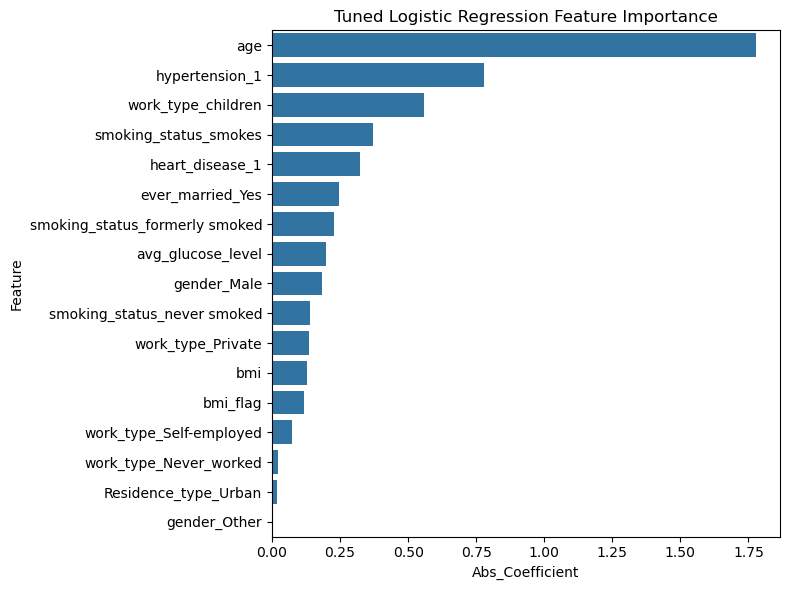

In [66]:
log_model = LogisticRegression(C=0.1,solver="lbfgs",penalty="l2",class_weight="balanced", random_state=42)

log_model.fit(X_train_s, y_train)
log_coef = log_model.coef_[0]

log_df = pd.DataFrame({
    "Feature": X_train_s.columns,
    "Coefficient": log_coef,
    "Abs_Coefficient": np.abs(log_coef)
}).sort_values(by="Abs_Coefficient", ascending=False)

print(log_df)

plt.figure(figsize=(8,6))
sns.barplot(x="Abs_Coefficient", y="Feature", data=log_df.head(20))
plt.title("Tuned Logistic Regression Feature Importance")
plt.tight_layout()
plt.show()


#### 2- LDA Feature Importance

                           Feature  Coefficient  Abs_Coefficient
15                  hypertension_1     1.685751         1.685751
0                              age     1.638660         1.638660
10              work_type_children     1.613169         1.613169
16                 heart_disease_1     1.148503         1.148503
6                 ever_married_Yes    -0.957429         0.957429
7           work_type_Never_worked     0.947085         0.947085
5                     gender_Other    -0.840710         0.840710
8                work_type_Private     0.418387         0.418387
1                avg_glucose_level     0.397348         0.397348
14           smoking_status_smokes     0.244536         0.244536
12  smoking_status_formerly smoked     0.164942         0.164942
2                              bmi    -0.150748         0.150748
4                      gender_Male    -0.142033         0.142033
13     smoking_status_never smoked     0.059031         0.059031
11            Residence_t

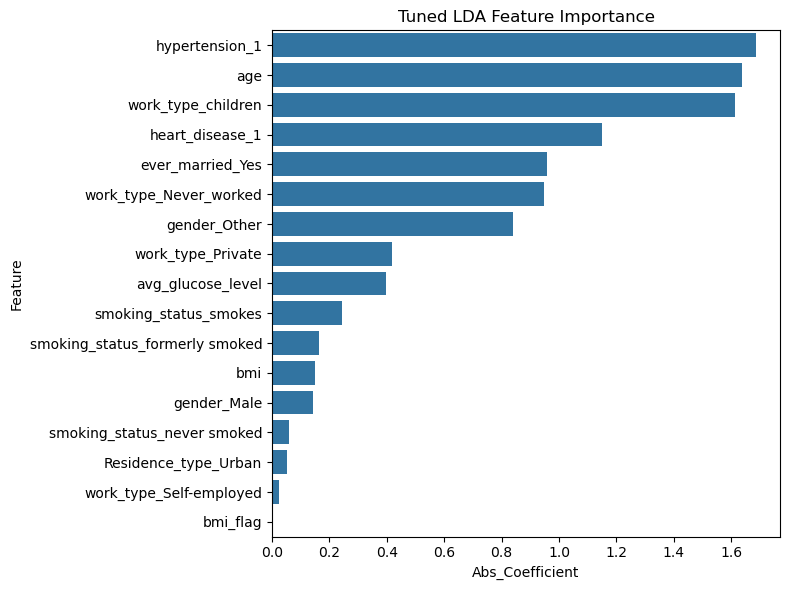

In [67]:
lda_model = LinearDiscriminantAnalysis(solver="svd")

lda_model.fit(X_train_s, y_train)

#Feature importance:
lda_coef = lda_model.coef_[0]

lda_df = pd.DataFrame({
    "Feature": X_train_s.columns,
    "Coefficient": lda_coef,
    "Abs_Coefficient": np.abs(lda_coef)
}).sort_values(by="Abs_Coefficient", ascending=False)

print(lda_df)

plt.figure(figsize=(8,6))
sns.barplot(x="Abs_Coefficient", y="Feature", data=lda_df.head(20))
plt.title("Tuned LDA Feature Importance")
plt.tight_layout()
plt.show()

#### 3- SVM Feature Importnace

                           Feature  Coefficient  Abs_Coefficient
10              work_type_children     1.645112         1.645112
0                              age     1.433191         1.433191
15                  hypertension_1     0.481517         0.481517
6                 ever_married_Yes    -0.352711         0.352711
16                 heart_disease_1     0.342634         0.342634
14           smoking_status_smokes     0.282614         0.282614
13     smoking_status_never smoked    -0.220878         0.220878
1                avg_glucose_level     0.169147         0.169147
12  smoking_status_formerly smoked     0.162678         0.162678
4                      gender_Male    -0.096602         0.096602
2                              bmi     0.048670         0.048670
8                work_type_Private     0.044657         0.044657
3                         bmi_flag    -0.022860         0.022860
11            Residence_type_Urban     0.018653         0.018653
9          work_type_Self

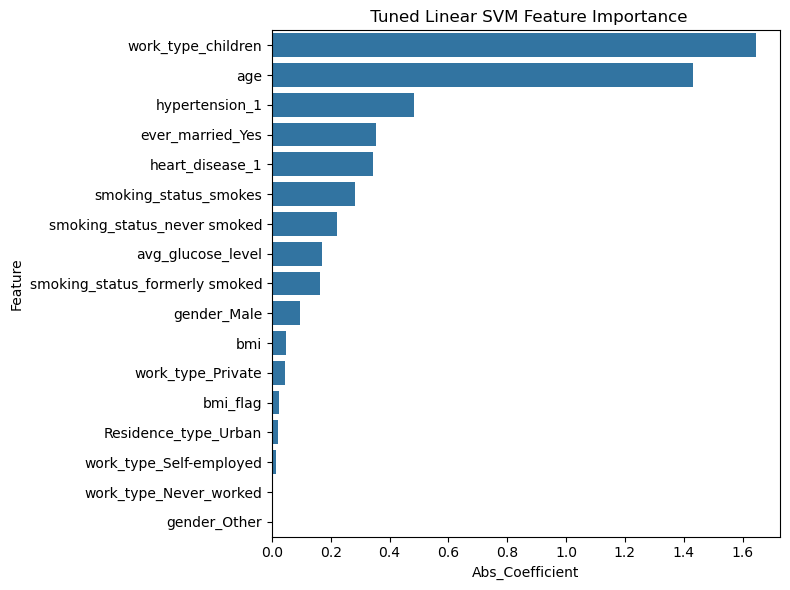

In [69]:
svm_model = SVC(C=0.5,class_weight="balanced",random_state=42,kernel="linear")
svm_model.fit(X_train_s, y_train)

svm_coef = svm_model.coef_[0]

svm_df = pd.DataFrame({
    "Feature": X_train_s.columns,
    "Coefficient": svm_coef,
    "Abs_Coefficient": np.abs(svm_coef)
}).sort_values(by="Abs_Coefficient", ascending=False)

print(svm_df)

plt.figure(figsize=(8,6))
sns.barplot(x="Abs_Coefficient", y="Feature", data=svm_df.head(20))
plt.title(" Tuned Linear SVM Feature Importance")
plt.tight_layout()
plt.show()

# 2 Regression

### Load Datasets

In [26]:

# =========================
# LOAD SAVED DATASETS
# =========================

# For Xgboost and Lightgbm
X_train_gb_reg  = pd.read_csv("X_train_gb_reg.csv")
X_test_gb_reg   = pd.read_csv("X_test_gb_reg.csv")
y_train_gb_reg  = pd.read_csv("y_train_gb_reg.csv").squeeze()
y_test_gb_reg   = pd.read_csv("y_test_gb_reg.csv").squeeze()

# For Tree based(Robust)
X_train_tree_reg = pd.read_csv("X_train_tree_reg.csv")
X_test_tree_reg  = pd.read_csv("X_test_tree_reg.csv")
y_train_tree_reg = pd.read_csv("y_train_tree_reg.csv").squeeze()
y_test_tree_reg  = pd.read_csv("y_test_tree_reg.csv").squeeze()

# For scale-sesitive models
X_train_s_reg  = pd.read_csv("X_train_s_reg.csv")
X_test_s_reg   = pd.read_csv("X_test_s_reg.csv")
y_train_reg  = pd.read_csv("y_train_reg.csv").squeeze()
y_test_reg  = pd.read_csv("y_test_reg.csv").squeeze()

# For Adaboost
X_train_ada_reg = pd.read_csv("X_train_ada_reg.csv")
X_test_ada_reg = pd.read_csv("X_test_ada_reg.csv")
y_train_ada_reg = pd.read_csv("y_train_ada_reg.csv").squeeze()
y_test_ada_reg  = pd.read_csv("y_test_ada_reg.csv").squeeze()

# For Catboost
X_train_ca_reg = pd.read_csv("X_train_ca_reg.csv")
X_test_ca_reg  = pd.read_csv("X_test_ca_reg.csv")
y_train_ca_reg = pd.read_csv("y_train_ca_reg.csv").squeeze()
y_test_ca_reg  = pd.read_csv("y_test_ca_reg.csv").squeeze()

# Regression Models

#### Linear Regression

In [27]:
import statsmodels.api as sm

# Add constant 
X_train_const = sm.add_constant(X_train_s_reg)

ols_model = sm.OLS(y_train_reg, X_train_const).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:          loan_int_rate   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     9619.
Date:                Sat, 14 Feb 2026   Prob (F-statistic):               0.00
Time:                        23:35:25   Log-Likelihood:                -32425.
No. Observations:               22782   AIC:                         6.490e+04
Df Residuals:                   22759   BIC:                         6.508e+04
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

In [28]:
# print pvalues of pridictors
ols_model.pvalues

const                          0.000000e+00
person_age                     1.103256e-01
person_income                  3.615869e-04
person_emp_length              4.375910e-02
loan_amnt                      1.400781e-10
loan_percent_income            1.850685e-05
cb_person_cred_hist_length     5.430468e-02
person_income_flag             6.814886e-02
person_home_ownership_OTHER    5.076940e-03
person_home_ownership_OWN      9.958092e-07
person_home_ownership_RENT     9.996672e-12
loan_intent_EDUCATION          7.450654e-01
loan_intent_HOMEIMPROVEMENT    1.968629e-01
loan_intent_MEDICAL            6.180361e-01
loan_intent_PERSONAL           7.109250e-01
loan_intent_VENTURE            4.311361e-01
cb_person_default_on_file_Y    4.972054e-01
loan_grade_B                   0.000000e+00
loan_grade_C                   0.000000e+00
loan_grade_D                   0.000000e+00
loan_grade_E                   0.000000e+00
loan_grade_F                   0.000000e+00
loan_grade_G                   0

#### Some predictors(Loan intent catagories)  showed p-values greater than 0.05, suggesting weak statisical significance when controlling for other variables

In [29]:

# =========================
# METRICS HELPERS
# =========================
def adjusted_r2(r2, n, p):
    if n <= p + 1:
        return np.nan
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)


def normalized_absolute_error(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    denom = np.mean(np.abs(y_true - np.mean(y_true))) + 1e-9
    return mae / denom


def eval_regressor(name, model, X_train, y_train, X_test, y_test):
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_r2 = cross_val_score(model, X_train, y_train, cv=cv, scoring="r2")

    model.fit(X_train, y_train)

    yhat_train = model.predict(X_train)
    yhat_test  = model.predict(X_test)

    train_r2 = r2_score(y_train, yhat_train)
    test_r2  = r2_score(y_test, yhat_test)

    train_adj = adjusted_r2(train_r2, n=X_train.shape[0], p=X_train.shape[1])
    test_adj  = adjusted_r2(test_r2,  n=X_test.shape[0],  p=X_test.shape[1])

    train_mae  = mean_absolute_error(y_train, yhat_train)
    test_mae   = mean_absolute_error(y_test, yhat_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, yhat_train))
    test_rmse  = np.sqrt(mean_squared_error(y_test, yhat_test))

    train_nae  = normalized_absolute_error(y_train, yhat_train)
    test_nae   = normalized_absolute_error(y_test, yhat_test)

    train_mape = mean_absolute_percentage_error(y_train, yhat_train) * 100
    test_mape  = mean_absolute_percentage_error(y_test, yhat_test) * 100

    print(f"\n============================================= {name} ========================================================")
    print("CV R2 Mean:", cv_r2.mean())

    print("\n--- TRAIN ---")
    print("R2:", train_r2)
    print("Adjusted R2:", train_adj)
    print("MAE:", train_mae)
    print("RMSE:", train_rmse)
    print("NAE:", train_nae)
    print("MAPE:",train_mape)

    print("\n--- TEST ---")
    print("R2:", test_r2)
    print("Adjusted R2:", test_adj)
    print("MAE:", test_mae)
    print("RMSE:", test_rmse)
    print("NAE:", test_nae)
    print("MAPE:",test_mape)

    return {
        "Model": name,
        "CV_R2": float(cv_r2.mean()),
        "Train_R2": float(train_r2),
        "Test_R2": float(test_r2),
        "Train_Adj_R2": None if np.isnan(train_adj) else float(train_adj),
        "Test_Adj_R2": None if np.isnan(test_adj) else float(test_adj),
        "Train_MAE": float(train_mae),
        "Test_MAE": float(test_mae),
        "Train_RMSE": float(train_rmse),
        "Test_RMSE": float(test_rmse),
        "Train_NAE": float(train_nae),
        "Test_NAE": float(test_nae),
        "Train_MAPE": float(train_mape),
        "Test_MAPE": float(test_mape)
    }


# =========================
#  MODELS 
# =========================
reg_results = []

# Scale-sensitive 
reg_results.append(eval_regressor("Linear Regression", LinearRegression(),
                                  X_train_s_reg, y_train_reg, X_test_s_reg, y_test_reg))

reg_results.append(eval_regressor("Ridge", Ridge(),
                                  X_train_s_reg, y_train_reg, X_test_s_reg, y_test_reg))

reg_results.append(eval_regressor("Lasso", Lasso(),
                                  X_train_s_reg, y_train_reg, X_test_s_reg, y_test_reg))

reg_results.append(eval_regressor("ElasticNet", ElasticNet(),
                                  X_train_s_reg, y_train_reg, X_test_s_reg, y_test_reg))

reg_results.append(eval_regressor("SVR (RBF)", SVR(kernel="rbf"),
                                  X_train_s_reg, y_train_reg, X_test_s_reg, y_test_reg))

reg_results.append(eval_regressor("KNN Regressor", KNeighborsRegressor(n_neighbors=5),
                                  X_train_s_reg, y_train_reg, X_test_s_reg, y_test_reg))


# Robust tree models 
reg_results.append(eval_regressor("Decision Tree Regressor", DecisionTreeRegressor(max_depth=10, random_state=42),
                                  X_train_tree_reg, y_train_tree_reg, X_test_tree_reg, y_test_tree_reg))

reg_results.append(eval_regressor("Random Forest Regressor", RandomForestRegressor(n_estimators=100, random_state=42),
                                  X_train_tree_reg, y_train_tree_reg, X_test_tree_reg, y_test_tree_reg))

reg_results.append(eval_regressor("Extra Trees Regressor", ExtraTreesRegressor(n_estimators=100, random_state=42),
                                  X_train_tree_reg, y_train_tree_reg, X_test_tree_reg, y_test_tree_reg))


# AdaBoost 
reg_results.append(eval_regressor("AdaBoost Regressor", AdaBoostRegressor(n_estimators=100, random_state=42),
                                  X_train_ada_reg, y_train_ada_reg, X_test_ada_reg, y_test_ada_reg))


# Gradient boosting 
reg_results.append(eval_regressor("XGBoost Regressor", XGBRegressor(n_estimators=100, random_state=42),
                                  X_train_gb_reg, y_train_gb_reg, X_test_gb_reg, y_test_gb_reg))

reg_results.append(eval_regressor("LightGBM Regressor", LGBMRegressor(n_estimators=100, random_state=42),
                                  X_train_gb_reg, y_train_gb_reg, X_test_gb_reg, y_test_gb_reg))

# CatBoost 
cat_idx = [i for i, c in enumerate(X_train_ca_reg.columns)
           if X_train_ca_reg[c].dtype == "object" or str(X_train_ca_reg[c].dtype) == "category"]

cat_params = dict(iterations=300, random_state=42, verbose=0)
if len(cat_idx) > 0:
    cat_params["cat_features"] = cat_idx

reg_results.append(eval_regressor("CatBoost Regressor", CatBoostRegressor(**cat_params),
                                  X_train_ca_reg, y_train_ca_reg, X_test_ca_reg, y_test_ca_reg))


# =========================
# SUMMARY + SAVE
# =========================
reg_results_df = pd.DataFrame(reg_results)

# Sort by Test_R2 (higher better), then Test_RMSE (lower better)
reg_results_df_sorted = reg_results_df.sort_values(["Test_R2", "Test_RMSE"], ascending=[False, True])

reg_results_df_sorted.to_csv("regression_model_results.csv", index=False)
print("\nSaved: regression_model_results.csv")



============================================= Linear Regression ========================================================
CV R2 Mean: 0.9026144891088542

--- TRAIN ---
R2: 0.9028972344035774
Adjusted R2: 0.9028033699612416
MAE: 0.7859025057517947
RMSE: 1.0043216047194408
NAE: 0.2941157537226209
MAPE: 7.957077571761779

--- TEST ---
R2: 0.9050280857643569
Adjusted R2: 0.9046612700843737
MAE: 0.7961862858558763
RMSE: 1.004835905277275
NAE: 0.29216221712057316
MAPE: 8.14811567929676

============================================= Ridge ========================================================
CV R2 Mean: 0.9025849004301829

--- TRAIN ---
R2: 0.9028760134178815
Adjusted R2: 0.902782128462268
MAE: 0.7855980946021587
RMSE: 1.004431341707759
NAE: 0.2940018310489285
MAPE: 7.956099038009907

--- TEST ---
R2: 0.905026126268799
Adjusted R2: 0.9046593030205394
MAE: 0.7959280638614624
RMSE: 1.0048462712962851
NAE: 0.2920674620214997
MAPE: 8.148247589674797

===========================================

In [30]:
reg_results_df_sorted

,Model,CV_R2,Train_R2,Test_R2,Train_Adj_R2,Test_Adj_R2,Train_MAE,Test_MAE,Train_RMSE,Test_RMSE,Train_NAE,Test_NAE,Train_MAPE,Test_MAPE
11,LightGBM Regressor,0.900901,0.915450,0.907551,0.915374,0.907220,0.740017,0.786751,0.940470,0.994148,0.275712,0.287648,7.561091,8.110565
12,CatBoost Regressor,0.904622,0.914404,0.906662,0.914367,0.906503,0.744236,0.791879,0.946270,0.998919,0.277283,0.289523,7.582544,8.147297
7,Random Forest Regressor,0.901926,0.986497,0.906476,0.986484,0.906131,0.290249,0.783353,0.374523,0.997147,0.108623,0.287453,2.926505,8.003345
0,Linear Regression,0.902614,0.902897,0.905028,0.902803,0.904661,0.785903,0.796186,1.004322,1.004836,0.294116,0.292162,7.957078,8.148116
1,Ridge,0.902585,0.902876,0.905026,0.902782,0.904659,0.785598,0.795928,1.004431,1.004846,0.294002,0.292067,7.956099,8.148248
10,XGBoost Regressor,0.901644,0.932533,0.904393,0.932472,0.904049,0.654206,0.800880,0.840108,1.010990,0.243741,0.292814,6.744958,8.227891
6,Decision Tree Regressor,0.896060,0.913303,0.900828,0.913223,0.900463,0.742198,0.808592,0.948984,1.026814,0.277760,0.296715,7.617312,8.234664
8,Extra Trees Regressor,0.894721,0.999993,0.898534,0.999993,0.898160,0.000097,0.814530,0.008747,1.038624,0.000036,0.298893,0.000961,8.307367
4,SVR (RBF),0.849685,0.869536,0.859635,0.869410,0.859093,0.834274,0.896635,1.164132,1.221594,0.312218,0.329022,8.377096,9.058343
5,KNN Regressor,0.657954,0.795227,0.682593,0.795029,0.681368,0.950716,1.207685,1.458457,1.836984,0.355795,0.443162,8.850878,11.258057


## Model Comparison

In [34]:
# Convert results list to DataFrame
results_df = pd.DataFrame(reg_results)

# Keep only selected columns
results_df = results_df[[
    "Model",
    "CV_R2",
    "Train_R2",
    "Test_R2",
    "Test_Adj_R2",
    "Test_MAE",
    "Test_RMSE",
    "Test_MAPE"
]]

# Sort: Higher Test R2 first, lower RMSE if tie
results_df = results_df.sort_values(
    by=["Test_R2", "Test_RMSE"],
    ascending=[False, True]
).reset_index(drop=True)

results_df.insert(0, "Rank", range(1, len(results_df) + 1))
results_df = results_df.round(4)

print("\n" + "=" * 100)
print("REGRESSION MODEL COMPARISON (Sorted by Test R²)")
print("=" * 50)
results_df



REGRESSION MODEL COMPARISON (Sorted by Test R²)


,Rank,Model,CV_R2,Train_R2,Test_R2,Test_Adj_R2,Test_MAE,Test_RMSE,Test_MAPE
0,1,LightGBM Regressor,0.9009,0.9154,0.9076,0.9072,0.7868,0.9941,8.1106
1,2,CatBoost Regressor,0.9046,0.9144,0.9067,0.9065,0.7919,0.9989,8.1473
2,3,Random Forest Regressor,0.9019,0.9865,0.9065,0.9061,0.7834,0.9971,8.0033
3,4,Linear Regression,0.9026,0.9029,0.9050,0.9047,0.7962,1.0048,8.1481
4,5,Ridge,0.9026,0.9029,0.9050,0.9047,0.7959,1.0048,8.1482
5,6,XGBoost Regressor,0.9016,0.9325,0.9044,0.9040,0.8009,1.0110,8.2279
6,7,Decision Tree Regressor,0.8961,0.9133,0.9008,0.9005,0.8086,1.0268,8.2347
7,8,Extra Trees Regressor,0.8947,1.0000,0.8985,0.8982,0.8145,1.0386,8.3074
8,9,SVR (RBF),0.8497,0.8695,0.8596,0.8591,0.8966,1.2216,9.0583
9,10,KNN Regressor,0.6580,0.7952,0.6826,0.6814,1.2077,1.8370,11.2581


In [32]:
# Print Top 3
print("\n" + "=" * 110)
print("TOP 3 REGRESSION MODELS")
print("=" * 110)
results_df.head(3)


TOP 3 REGRESSION MODELS


,Rank,Model,CV_R2,Train_R2,Test_R2,Test_Adj_R2,Test_MAE,Test_RMSE,Test_MAPE
0,1,LightGBM Regressor,0.9009,0.9154,0.9076,0.9072,0.7868,0.9941,8.1106
1,2,CatBoost Regressor,0.9046,0.9144,0.9067,0.9065,0.7919,0.9989,8.1473
2,3,Random Forest Regressor,0.9019,0.9865,0.9065,0.9061,0.7834,0.9971,8.0033


# Hyperparameter Tuning

#### Tuned Models

In [60]:
def adjusted_r2(r2, n, p):
    if n <= p + 1:
        return np.nan
    return 1 - ((1 - r2) * (n - 1) / (n - p - 1))

def safe_mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    denom = np.where(np.abs(y_true) < 1e-8, 1e-8, np.abs(y_true))
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)


cv = KFold(n_splits=3, shuffle=True, random_state=42)  # faster than 5-fold


def tune_and_eval(model_name, model, param_grid, X_train, y_train, X_test, y_test):
    gs = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring="r2",
        cv=cv,
        n_jobs=-1,)

    if model_name=="CatBoost Regressor":
        cat_cols=["person_home_ownership","loan_intent","cb_person_default_on_file","loan_grade"]
        cat_features=[X_train.columns.get_loc(c) for c in cat_cols if c in X_train.columns]
        gs.fit(X_train, y_train,cat_features=cat_features)
    else:
        gs.fit(X_train, y_train)
    best = gs.best_estimator_

    # Predict
    yhat_train = best.predict(X_train)
    yhat_test  = best.predict(X_test)

    # Metrics
    train_r2 = r2_score(y_train, yhat_train)
    test_r2  = r2_score(y_test,  yhat_test)

    train_adj = adjusted_r2(train_r2, len(y_train), X_train.shape[1])
    test_adj  = adjusted_r2(test_r2,  len(y_test),  X_test.shape[1])

    test_mae  = mean_absolute_error(y_test, yhat_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, yhat_test))
    test_mape = safe_mape(y_test, yhat_test)

    print("\n" + "="*70)
    print("Tuned",model_name)
    print("Best Params:", gs.best_params_)
    print("CV R2:", round(gs.best_score_, 4))
    print("--- TEST ---")
    print("R2:", round(test_r2, 4))
    print("Adj R2:", round(test_adj, 4))
    print("MAE:", round(test_mae, 4))
    print("RMSE:", round(test_rmse, 4))
    print("MAPE(%):", round(test_mape, 2))

    return {
        "Model":f"Tuned { model_name}",
        "CV_R2": float(gs.best_score_),
        "Train_R2": float(train_r2),
        "Test_R2": float(test_r2),
        "Test_Adj_R2": float(test_adj),
        "Test_MAE": float(test_mae),
        "Test_RMSE": float(test_rmse),
        "Test_MAPE": float(test_mape),
        "Best_Params": str(gs.best_params_)
    }


# =========================
# TUNED MODELS 
# =========================
tasks = [
    ("Linear Regression", LinearRegression(),{},X_train_s_reg, y_train_reg, X_test_s_reg, y_test_reg),
    
    ("Ridge", Ridge(random_state=42), {"alpha": [0.1, 1, 10]}, X_train_s_reg, y_train_reg, X_test_s_reg, y_test_reg),

    ("Lasso", Lasso(random_state=42, max_iter=10000),
     {"alpha": [0.001, 0.01, 0.1]}, X_train_s_reg, y_train_reg, X_test_s_reg, y_test_reg),


    ("KNN Regressor", KNeighborsRegressor(),
     {"n_neighbors": [3, 5, 9], "weights": ["uniform", "distance"]},
     X_train_s_reg, y_train_reg, X_test_s_reg, y_test_reg),

    ("Decision Tree Regressor", DecisionTreeRegressor(random_state=42),
     {"max_depth": [None, 10, 20], "min_samples_split": [2, 5]},
     X_train_tree_reg, y_train_tree_reg, X_test_tree_reg, y_test_tree_reg),

    ("Random Forest Regressor", RandomForestRegressor(random_state=42),
     {"n_estimators": [300,500 ], "max_depth": [6,10, 20], "min_samples_split": [2, 5]},
     X_train_tree_reg, y_train_tree_reg, X_test_tree_reg, y_test_tree_reg),

    ("AdaBoost Regressor", AdaBoostRegressor(random_state=42),
     {"n_estimators": [300, 500], "learning_rate": [0.05, 0.1]},
     X_train_ada_reg, y_train_ada_reg, X_test_ada_reg, y_test_ada_reg),

    ("XGBoost Regressor", XGBRegressor(random_state=42),
     {"n_estimators": [500, 800], "max_depth": [3, 5], "learning_rate": [0.05, 0.1]},
     X_train_gb_reg, y_train_gb_reg, X_test_gb_reg, y_test_gb_reg),

    ("LightGBM Regressor", LGBMRegressor(random_state=42),
     {"n_estimators": [300, 600], "num_leaves": [31, 63], "learning_rate": [0.05, 0.1]},
     X_train_gb_reg, y_train_gb_reg, X_test_gb_reg, y_test_gb_reg),

    ("CatBoost Regressor", CatBoostRegressor(random_state=42, verbose=0),
     {"iterations": [300, 600], "depth": [6, 8], "learning_rate": [0.05, 0.1]},
     X_train_ca_reg, y_train_ca_reg, X_test_ca_reg, y_test_ca_reg),
]


# =========================
# RUN ALL + BUILD TABLE
# =========================
compare_results = []

for name, model, grid, Xtr, ytr, Xte, yte in tasks:
    if grid == {}:
        model.fit(Xtr, ytr)
        yhat_test = model.predict(Xte)
        test_r2 = r2_score(yte, yhat_test)
        test_adj = adjusted_r2(test_r2, len(yte), Xte.shape[1])
        test_mae = mean_absolute_error(yte, yhat_test)
        test_rmse = np.sqrt(mean_squared_error(yte, yhat_test))
        test_mape = safe_mape(yte, yhat_test)

        compare_results.append({
            "Model": name,
            "CV_R2": np.nan,
            "Train_R2": float(model.score(Xtr, ytr)),
            "Test_R2": float(test_r2),
            "Test_Adj_R2": float(test_adj),
            "Test_MAE": float(test_mae),
            "Test_RMSE": float(test_rmse),
            "Test_MAPE": float(test_mape),
            "Best_Params": "{}"
        })
        print("\n" + "="*70)
        print(name)
        print("--- TEST ---")
        print("R2:", round(test_r2, 4))
        print("Adj R2:", round(test_adj, 4))
        print("MAE:", round(test_mae, 4))
        print("RMSE:", round(test_rmse, 4))
        print("MAPE(%):", round(test_mape, 2))
    else:
        compare_results.append(
            tune_and_eval(name, model, grid, Xtr, ytr, Xte, yte)
        )

results_df = pd.DataFrame(compare_results)




Linear Regression
--- TEST ---
R2: 0.905
Adj R2: 0.9047
MAE: 0.7962
RMSE: 1.0048
MAPE(%): 8.15

Tuned Ridge
Best Params: {'alpha': 0.1}
CV R2: 0.9026
--- TEST ---
R2: 0.905
Adj R2: 0.9047
MAE: 0.7961
RMSE: 1.0048
MAPE(%): 8.15

Tuned Lasso
Best Params: {'alpha': 0.001}
CV R2: 0.9026
--- TEST ---
R2: 0.905
Adj R2: 0.9046
MAE: 0.7956
RMSE: 1.005
MAPE(%): 8.15

Tuned KNN Regressor
Best Params: {'n_neighbors': 5, 'weights': 'distance'}
CV R2: 0.6506
--- TEST ---
R2: 0.6944
Adj R2: 0.6932
MAE: 1.1874
RMSE: 1.8026
MAPE(%): 11.11

Tuned Decision Tree Regressor
Best Params: {'max_depth': 10, 'min_samples_split': 5}
CV R2: 0.8949
--- TEST ---
R2: 0.901
Adj R2: 0.9006
MAE: 0.8086
RMSE: 1.0261
MAPE(%): 8.23

Tuned Random Forest Regressor
Best Params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 500}
CV R2: 0.9036
--- TEST ---
R2: 0.9067
Adj R2: 0.9064
MAE: 0.7878
RMSE: 0.9959
MAPE(%): 8.07

Tuned AdaBoost Regressor
Best Params: {'learning_rate': 0.05, 'n_estimators': 500}
CV R2: 0.5

In [61]:
results_df

,Model,CV_R2,Train_R2,Test_R2,Test_Adj_R2,Test_MAE,Test_RMSE,Test_MAPE,Best_Params
0,Linear Regression,NaN,0.902897,0.905028,0.904661,0.796186,1.004836,8.148116,{}
1,Tuned Ridge,0.902630,0.902897,0.905030,0.904663,0.796142,1.004827,8.148033,{'alpha': 0.1}
2,Tuned Lasso,0.902563,0.902779,0.904989,0.904622,0.795637,1.005044,8.150951,{'alpha': 0.001}
3,Tuned KNN Regressor,0.650587,0.999993,0.694378,0.693198,1.187403,1.802560,11.105211,"{'n_neighbors': 5, 'weights': 'distance'}"
4,Tuned Decision Tree Regressor,0.894879,0.912276,0.900961,0.900596,0.808561,1.026127,8.234493,"{'max_depth': 10, 'min_samples_split': 5}"
5,Tuned Random Forest Regressor,0.903555,0.915946,0.906702,0.906359,0.787841,0.995939,8.072943,"{'max_depth': 10, 'min_samples_split': 5, 'n_e..."
6,Tuned AdaBoost Regressor,0.552942,0.555919,0.558449,0.556744,1.791684,2.166645,19.613357,"{'learning_rate': 0.05, 'n_estimators': 500}"
7,Tuned XGBoost Regressor,0.904817,0.908714,0.906675,0.906340,0.790951,0.998851,8.154344,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est..."
8,Tuned LightGBM Regressor,0.901200,0.919284,0.907877,0.907547,0.785114,0.992394,8.095896,"{'learning_rate': 0.05, 'n_estimators': 300, '..."
9,Tuned CatBoost Regressor,0.905267,0.910903,0.906960,0.906801,0.789498,0.997325,8.122801,"{'depth': 6, 'iterations': 600, 'learning_rate..."


In [63]:
# Sort by Test R2 (high) then Test RMSE (low)
results_df = results_df.sort_values(
    by=["Test_R2", "Test_RMSE"],
    ascending=[False, True]
).reset_index(drop=True)

results_df.insert(0, "Rank", results_df.index + 1)
print("\n" + "="*110)
print("TUNED MODELS COMPARISON TABLE (Sorted by Test R2 then Test RMSE)")
print("="*110)
result_df=results_df[[
    "Rank","Model","CV_R2","Train_R2","Test_R2","Test_Adj_R2","Test_MAE","Test_RMSE","Test_MAPE"
]].round(4)
result_df


TUNED MODELS COMPARISON TABLE (Sorted by Test R2 then Test RMSE)


,Rank,Model,CV_R2,Train_R2,Test_R2,Test_Adj_R2,Test_MAE,Test_RMSE,Test_MAPE
0,1,Tuned LightGBM Regressor,0.9012,0.9193,0.9079,0.9075,0.7851,0.9924,8.0959
1,2,Tuned CatBoost Regressor,0.9053,0.9109,0.9070,0.9068,0.7895,0.9973,8.1228
2,3,Tuned Random Forest Regressor,0.9036,0.9159,0.9067,0.9064,0.7878,0.9959,8.0729
3,4,Tuned XGBoost Regressor,0.9048,0.9087,0.9067,0.9063,0.7910,0.9989,8.1543
4,5,Tuned Ridge,0.9026,0.9029,0.9050,0.9047,0.7961,1.0048,8.1480
5,6,Linear Regression,NaN,0.9029,0.9050,0.9047,0.7962,1.0048,8.1481
6,7,Tuned Lasso,0.9026,0.9028,0.9050,0.9046,0.7956,1.0050,8.1510
7,8,Tuned Decision Tree Regressor,0.8949,0.9123,0.9010,0.9006,0.8086,1.0261,8.2345
8,9,Tuned KNN Regressor,0.6506,1.0000,0.6944,0.6932,1.1874,1.8026,11.1052
9,10,Tuned AdaBoost Regressor,0.5529,0.5559,0.5584,0.5567,1.7917,2.1666,19.6134


In [67]:
print("\nTOP 3 (TUNED):")
result_df.head(3)


TOP 3 (TUNED):


,Rank,Model,CV_R2,Train_R2,Test_R2,Test_Adj_R2,Test_MAE,Test_RMSE,Test_MAPE
0,1,Tuned LightGBM Regressor,0.9012,0.9193,0.9079,0.9075,0.7851,0.9924,8.0959
1,2,Tuned CatBoost Regressor,0.9053,0.9109,0.9070,0.9068,0.7895,0.9973,8.1228
2,3,Tuned Random Forest Regressor,0.9036,0.9159,0.9067,0.9064,0.7878,0.9959,8.0729


In [68]:
result_df.to_csv("tuned_regression_model_comparison.csv", index=False)
print("\nSaved: tuned_regression_model_comparison.csv")


Saved: tuned_regression_model_comparison.csv


### Top 3 Models Feature Importance

#### 1-Lightgbm feature importance

In [38]:
lgbm_model=LGBMRegressor(n_estimators=300,num_leaves=31,learning_rate=0.05,random_state=42,n_jobs=-1)
lgbm_model.fit(X_train_gb_reg,y_train_gb_reg)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000936 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 697
[LightGBM] [Info] Number of data points in the train set: 23450, number of used features: 21
[LightGBM] [Info] Start training from score 11.033976


LGBMRegressor(learning_rate=0.05, n_estimators=300, n_jobs=-1, random_state=42)

In [39]:
lgbm_importance=lgbm_model.feature_importances_
lgbm_df=pd.DataFrame({"Feature":X_train_gb_reg.columns,
                      "Importance":lgbm_importance}).sort_values(by="Importance",ascending=False)
lgbm_df

,Feature,Importance
1,person_income,1742
3,loan_amnt,1621
2,person_emp_length,1252
0,person_age,937
4,loan_percent_income,920
5,cb_person_cred_hist_length,613
16,loan_grade_C,231
17,loan_grade_D,219
15,loan_grade_B,209
8,person_home_ownership_RENT,189


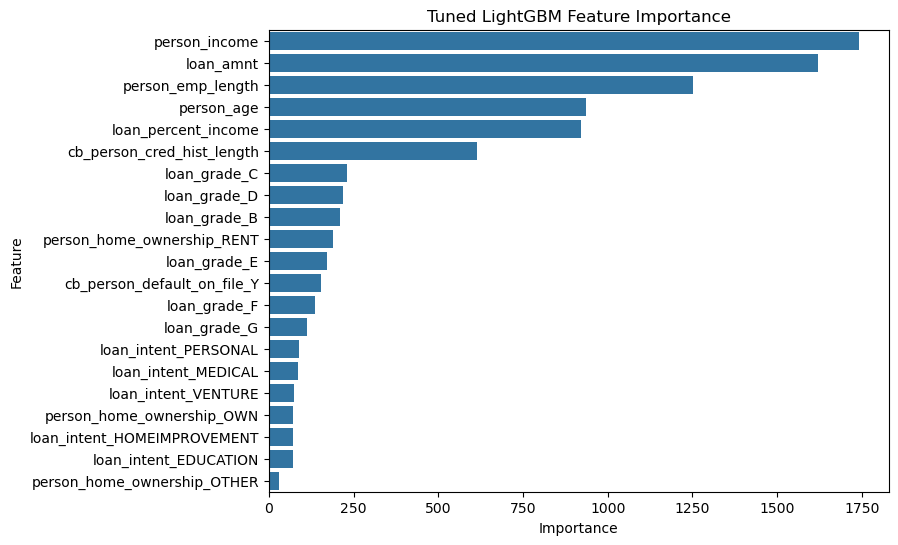

In [47]:
# Visualization
plt.figure(figsize=(8,6))
sns.barplot(x="Importance",y="Feature",data=lgbm_df)
plt.title("Tuned LightGBM Feature Importance")
plt.show()

#### 2- Catboost feature importance

In [51]:
# Identify categorical columns
cat_cols = [c for c in X_train_ca_reg.columns
            if (X_train_ca_reg[c].dtype == "object") or (str(X_train_ca_reg[c].dtype) == "category")]

cat_model = CatBoostRegressor(iterations=600,depth=6, learning_rate=0.05,random_state=42,verbose=0)
cat_model.fit(X_train_ca_reg, y_train_ca_reg,cat_features=cat_cols)

                      Feature  Importance
9                  loan_grade   94.814564
3                   loan_amnt    1.202774
2           person_emp_length    0.946297
1               person_income    0.686646
6       person_home_ownership    0.606245
4         loan_percent_income    0.491141
0                  person_age    0.459853
7                 loan_intent    0.400825
5  cb_person_cred_hist_length    0.334543
8   cb_person_default_on_file    0.057113


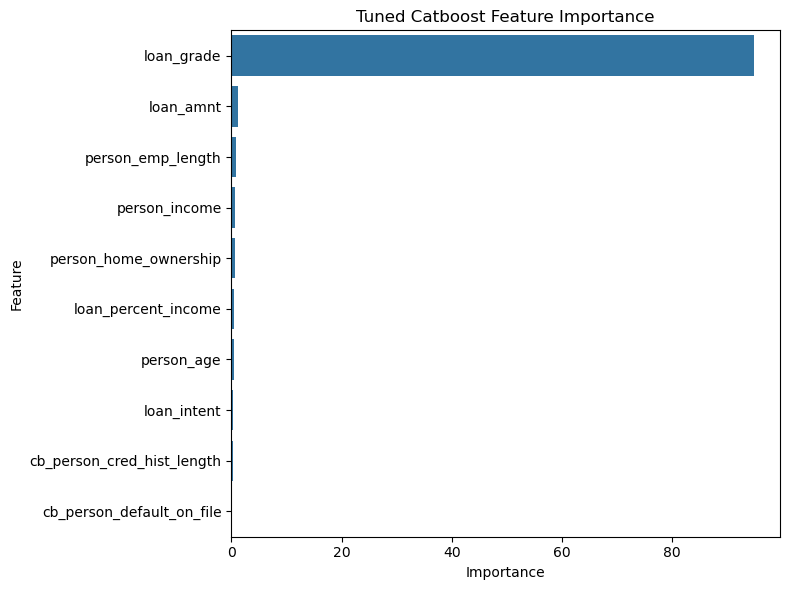

In [58]:
cat_imp = cat_model.get_feature_importance()
cat_imp_df = pd.DataFrame({"Feature": X_train_ca_reg.columns, "Importance": cat_imp}).sort_values("Importance", ascending=False)
print(cat_imp_df)

plt.figure(figsize=(8,6))
sns.barplot(x="Importance", y="Feature", data=cat_imp_df.head(20))
plt.title("Tuned Catboost Feature Importance")
plt.tight_layout()
plt.show()

#### 3-RandomForest Feature Importance

In [55]:
rf_model = RandomForestRegressor( n_estimators=500,max_depth=10,min_samples_split=5,random_state=42,n_jobs=-1)
rf_model.fit(X_train_tree_reg, y_train_tree_reg)

RandomForestRegressor(max_depth=10, min_samples_split=5, n_estimators=500,
                      n_jobs=-1, random_state=42)

                        Feature  Importance
14  cb_person_default_on_file_Y    0.271239
16                 loan_grade_C    0.172942
17                 loan_grade_D    0.164787
15                 loan_grade_B    0.162307
18                 loan_grade_E    0.144514
19                 loan_grade_F    0.053247
20                 loan_grade_G    0.015595
3                     loan_amnt    0.003576
1                 person_income    0.002853
4           loan_percent_income    0.002250
2             person_emp_length    0.002205
0                    person_age    0.001400
5    cb_person_cred_hist_length    0.001115
8    person_home_ownership_RENT    0.000581
12         loan_intent_PERSONAL    0.000312
10  loan_intent_HOMEIMPROVEMENT    0.000218
11          loan_intent_MEDICAL    0.000204
7     person_home_ownership_OWN    0.000189
13          loan_intent_VENTURE    0.000186
9         loan_intent_EDUCATION    0.000157
6   person_home_ownership_OTHER    0.000123


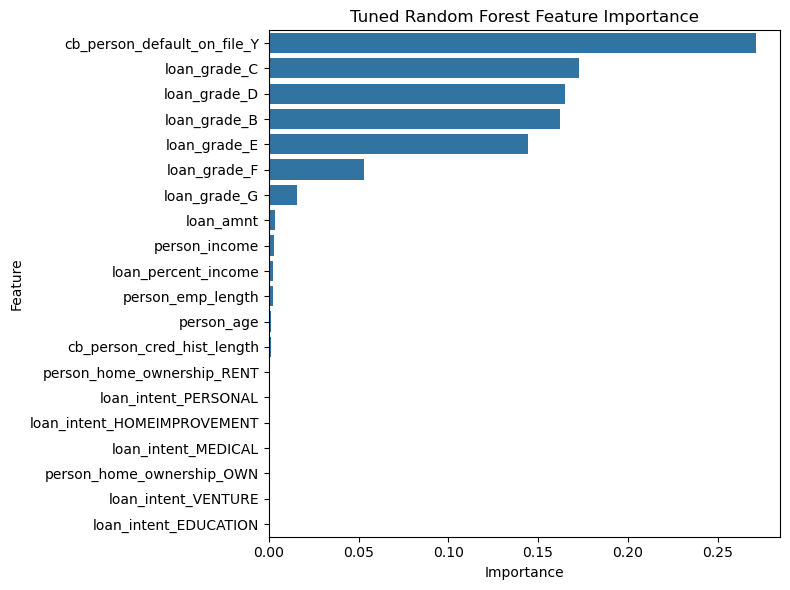

In [56]:
rf_importance = rf_model.feature_importances_

rf_df = pd.DataFrame({
    "Feature": X_train_tree_reg.columns,
    "Importance": rf_importance
}).sort_values(by="Importance", ascending=False)

print(rf_df)

plt.figure(figsize=(8,6))
sns.barplot(x="Importance", y="Feature", data=rf_df.head(20))
plt.title("Tuned Random Forest Feature Importance")
plt.tight_layout()
plt.show()